# 1. Cargar bibliotecas y csv

In [100]:
import os
import requests
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import pickle
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import xgboost as xgb
import shap

In [101]:
df = pd.read_csv("/workspaces/steven10015-intro-ml/data/raw/medical_insurance_cost.csv")
# Fijar el id como indice
pd.set_option('display.max_columns', None)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [102]:
df.shape

(1338, 7)

# 2. Cribado manual

In [103]:
unicos = df.nunique()
df[unicos[unicos==1].index]

""
0
1
2
3
4
...
1333
1334
1335
1336


In [104]:
dup_fil=df.duplicated().sum()
print("No hay filas duplicadas" if dup_fil==0 else "Hay filas duplicadas")

Hay filas duplicadas


In [105]:
df.drop_duplicates(inplace=True)

In [106]:
dup_col=df.T.duplicated(keep=False).sum()
print("No hay variables exactamente iguales" if dup_col==0 else "Hay variables exactamente iguales")

No hay variables exactamente iguales


In [107]:
df.shape

(1337, 7)

In [108]:
missing=df.isna().mean()*100
print(missing)
total_filas_con_na = df.isna().any(axis=1).sum()
print(f"Total de filas con al menos un dato faltante: {total_filas_con_na}")

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64
Total de filas con al menos un dato faltante: 0


<Axes: >

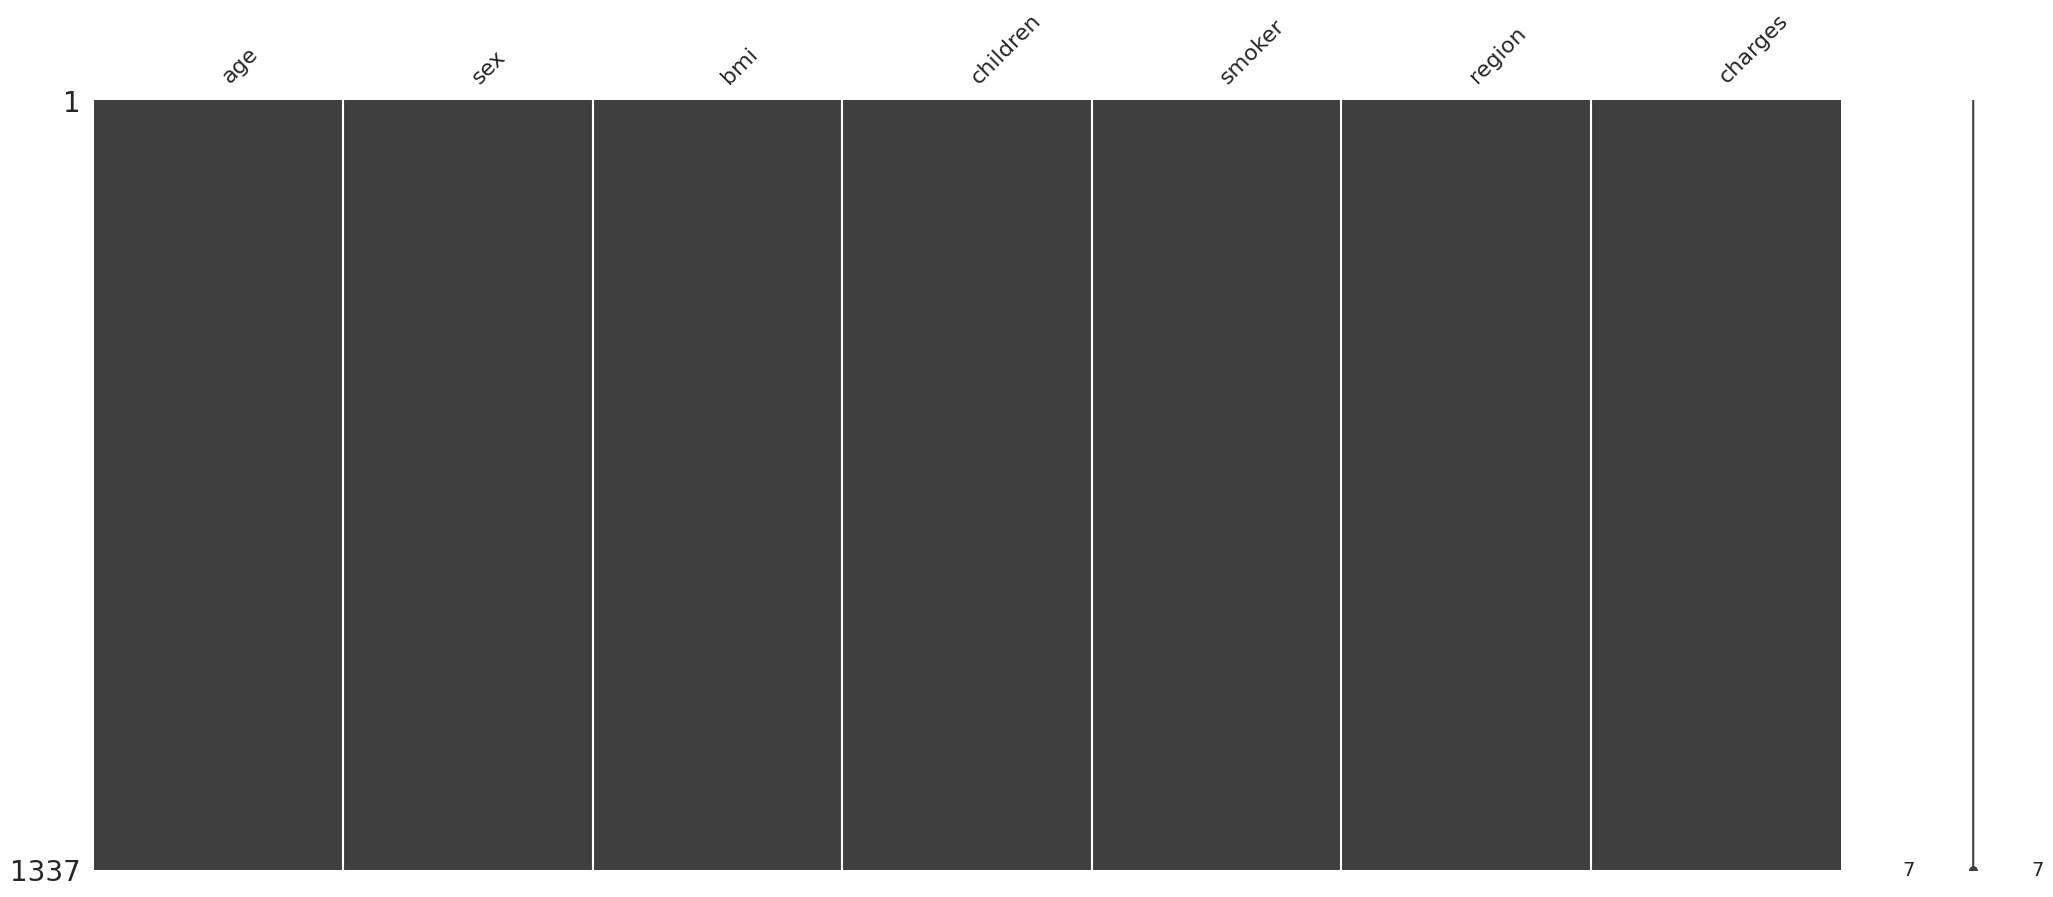

In [109]:
msno.matrix(df)

# 3. Variables categóricas

In [110]:
df = pd.get_dummies(df, columns=['sex'])
columnas_sexo_codificadas = [col for col in df.columns if col.startswith('Sexo_')] 
df[columnas_sexo_codificadas] = df[columnas_sexo_codificadas].astype(int)
#  Eliminar una de las columnas de sexo 
# Si sex_female es True, sex_male será False por definición. 
# Tener ambas crea multicolinealidad perfecta, lo que puede afectar el modelo.
df = df.drop('sex_male', axis=1)

# Convertir 'smoker' a binario (0 y 1)
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

# Convertir 'region' en variables dummies
# Usamos drop_first=True para evitar la "trampa de las variables ficticias"
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [111]:
# Convertir todas las columnas booleanas a enteros (0 y 1)
columnas_bool = df.select_dtypes(include=['bool']).columns
df[columnas_bool] = df[columnas_bool].astype(int)

In [112]:
df.head()

,age,bmi,children,smoker,charges,sex_female,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,16884.92400,1,0,0,1
1,18,33.770,1,0,1725.55230,0,0,1,0
2,28,33.000,3,0,4449.46200,0,0,1,0
3,33,22.705,0,0,21984.47061,0,1,0,0
4,32,28.880,0,0,3866.85520,0,1,0,0


# 4. División train/test

In [113]:
# Definir X (predictores) y y (objetivo)
X = df.drop('charges', axis=1)
y = df['charges']

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Selección de caracteristicas

In [114]:
# 1. Random Forest Regressor (Cribado rápido de importancia intrínseca)
rf = RandomForestRegressor(random_state=42, n_jobs=-1).fit(X_train, y_train)
df_rf = pd.DataFrame({'feature': X_train.columns, 'rf': rf.feature_importances_ * 100})

# 2. Permutación con XGBoost (Mide qué variables rompen el modelo si las quitamos)
xgb_mod = xgb.XGBRegressor(random_state=42).fit(X_train, y_train)
perm = permutation_importance(xgb_mod, X_test, y_test, n_repeats=5, scoring='r2', n_jobs=-1)
df_perm = pd.DataFrame({'feature': X_train.columns, 'perm': perm.importances_mean * 100})

# 3. SHAP (Mide la contribución marginal de cada variable)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
# En regresión, tomamos la media del valor absoluto de los SHAP values
imp_shap = np.abs(shap_values).mean(axis=0) 
df_shap = pd.DataFrame({'feature': X_train.columns, 'shap': (imp_shap / imp_shap.sum()) * 100})

# 4. Consenso y Filtrado
# Unimos los tres métodos en un solo DataFrame
df_importances = df_rf.merge(df_perm, on='feature').merge(df_shap, on='feature')

# Aplicamos el filtro: la variable debe aportar al menos 1% en los TRES métodos
df_filt = df_importances[
    (df_importances['rf'] >= 1) & 
    (df_importances['perm'] >= 1) & 
    (df_importances['shap'] >= 1)
].sort_values(by='rf', ascending=False)

print("\n--- Variables seleccionadas por consenso (mínimo 1% de aporte) ---")
print(df_filt)


--- Variables seleccionadas por consenso (mínimo 1% de aporte) ---
  feature         rf        perm       shap
3  smoker  60.077698  141.545305  53.649172
1     bmi  21.584679   24.295194  15.053834
0     age  13.584782   17.108392  21.671148


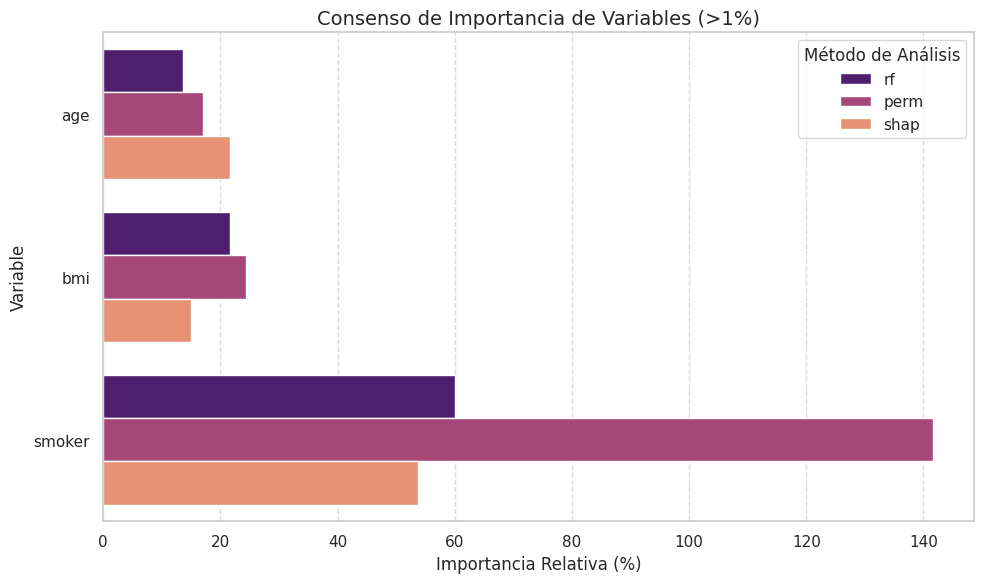

In [115]:
# --- Gráfica de Consenso de Importancias ---
plt.figure(figsize=(10, 6))

# Transformamos el dataframe a formato "largo" para que Seaborn lo entienda mejor
df_plot = df_importances.melt(id_vars='feature', var_name='Metodo', value_name='Importancia')

# Filtramos solo las variables que pasaron el filtro para que la gráfica sea limpia
df_plot = df_plot[df_plot['feature'].isin(df_filt['feature'])]

sns.barplot(data=df_plot, x='Importancia', y='feature', hue='Metodo', palette='magma')

plt.title('Consenso de Importancia de Variables (>1%)', fontsize=14)
plt.xlabel('Importancia Relativa (%)')
plt.ylabel('Variable')
plt.legend(title='Método de Análisis')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 5. Modelo

In [116]:
# 1. Seleccionamos solo las variables que el consenso validó (las que aportan > 1%)
features_finales = ['smoker', 'bmi', 'age', 'children']
X_train_f = X_train[features_finales]
X_test_f = X_test[features_finales]

# 2. Entrenamiento directo
model = LinearRegression()
model.fit(X_train_f, y_train)

# 3. Predicción y Métricas clave
y_pred = model.predict(X_test_f)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Modelo Final (Variables: {features_finales})")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

# 4. Lo más útil para el negocio: ¿Cuánto dinero suma cada factor?
analisis = pd.DataFrame({'Factor': features_finales, 'Impacto_USD': model.coef_})
print("\nInterpretación de la prima:")
print(analisis.sort_values(by='Impacto_USD', ascending=False))

Modelo Final (Variables: ['smoker', 'bmi', 'age', 'children'])
R² Score: 0.8046
RMSE: 5992.88

Interpretación de la prima:
     Factor   Impacto_USD
0    smoker  23042.507238
3  children    537.972196
1       bmi    305.267404
2       age    249.191292


# 6. Optimización

In [117]:
features = ['smoker', 'bmi', 'age', 'children']
model = LinearRegression().fit(X_train[features], y_train)

# Métricas de validación
y_pred = model.predict(X_test[features])
print(f"Precisión (R2): {r2_score(y_test, y_pred):.4f}")
print(f"Error promedio (RMSE): ${np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# --- FUNCIÓN PARA COTIZAR UN NUEVO CLIENTE ---
def cotizar(smoker, bmi, age, children):
    # smoker: 1 para sí, 0 para no
    datos = pd.DataFrame([[smoker, bmi, age, children]], columns=features)
    precio = model.predict(datos)[0]
    return f"La prima estimada es de: ${precio:,.2f} USD"

# Ejemplo: Cliente de 30 años, IMC 25, no fumador, 0 hijos
print(cotizar(smoker=0, bmi=25, age=30, children=0))

Precisión (R2): 0.8046
Error promedio (RMSE): $5992.88
La prima estimada es de: $3,850.67 USD


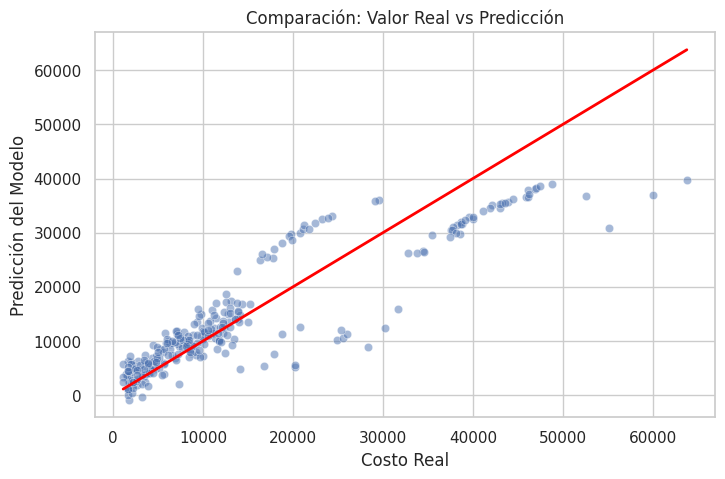

In [118]:
# 1. Definir el tamaño
plt.figure(figsize=(8, 5))

# 2. Dibujar los puntos (Real vs Predicho)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)

# 3. Dibujar la línea de "perfección" (donde Real == Predicho)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)

# 4. Etiquetas básicas
plt.title('Comparación: Valor Real vs Predicción')
plt.xlabel('Costo Real')
plt.ylabel('Predicción del Modelo')
plt.show()

# 7. Guardar modelo

In [119]:
# 1. Definimos la ruta absoluta (adaptada a tu entorno de Codespaces/Gitpod)
folder_path = '/workspaces/steven10015-intro-ml/models'

# 2. Creamos la carpeta si no existe
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# 3. Guardamos el modelo de Regresión Lineal
with open(os.path.join(folder_path, 'insurance_model.pkl'), 'wb') as f:
    pickle.dump(model, f)

# 4. Guardamos la lista de columnas seleccionadas (smoker, bmi, age, children)
# Esto garantiza que cuando cargues el modelo, sepas qué columnas pasarle.
with open(os.path.join(folder_path, 'model_columns.pkl'), 'wb') as f:
    pickle.dump(features_finales, f)

# 5. Guardamos un diccionario de métricas (opcional, muy útil para el reporte)
metrics = {'r2': 0.8046, 'rmse': 5992.88}
with open(os.path.join(folder_path, 'model_metrics.pkl'), 'wb') as f:
    pickle.dump(metrics, f)

print(f"✅ Modelo de regresión y configuración guardados en: {folder_path}")

✅ Modelo de regresión y configuración guardados en: /workspaces/steven10015-intro-ml/models
